<h1 align="center"> Projeto 4 </h1>
<center><h3> Álgebra Linear Numérica </h3></center>
<p align="center"> Participantes: Pedro Ricardo Alves e Elainne Rohs </p>

### Questão 1. Cálculo dos refletores

#### Letra a)

O refletor de Householder $Q_v = I - \beta v v^*$ tal que $Q_v x =\|x\| e_1$ o que faz é refletir $x$ em relação ao hiperplano perpendicular a $v$ para que se alinhe com $ e_1$. Por isso, $v = x - \|x\| e_1$. 

Multiplicando $x$ à equação que define o refletor:
$$ Q_v x = x - \beta v (v^* x) = \|x\| e_1 \implies x - \|x\| e_1 = \beta (v^* x) v $$

Sabendo que $\beta (v^* x)$ é um escalar igual a 1, vamos calcular $v^* x$:
$$ v^* x = (x - \|x\| e_1)^* x = \|x\|^2 - \|x\| x_1 $$
E assim, isolando $\beta$, temos:
$$ \beta = \frac{1}{v^* x} = \frac{1}{\|x\|^2 - \|x\|x_1} = \frac{1}{\|x\|(\|x\| - x_1)} $$
Para obter a segunda fórmula, multiplicamos o numerador e o denominador pelo conjugado $(\|x\| + x_1)$:
$$ \beta = \frac{\|x\| + x_1}{\|x\|(\|x\| - x_1)(\|x\| + x_1)} = \frac{\|x\| + x_1}{\|x\|(\|x\|^2 - x_1^2)} $$
Como $\|x\|^2 = \sum_{i=1}^n x_i^2$, temos que $\|x\|^2 - x_1^2 = \sum_{i=2}^n x_i^2 = \|y\|^2$, onde $y = (x_2, \dots, x_n)$. Substituindo:
$$ \beta = \frac{\|x\| + x_1}{\|x\| \|y\|^2} $$

-------------------------------------------

#### Letra b)

Se $x_1 > 0$ e o vetor for quase colinear a $e_1$ (ou seja, $x_1 \approx \|x\|$), a operação $(\|x\| - x_1)$, que é um fator do denominador de $\beta$, sofrerá de cancelamento numérico, pois subtrairemos dois números muito próximos, perdendo precisão nos dígitos significativos. Assim, $\beta$ tenderá ao infinito. 

Inversamente, se $x_1 < 0$, a fórmula do $\beta$ é estável.

----------------------------

#### Letra c)

In [17]:
using LinearAlgebra
using Plots

In [ ]:
function reflector(x)
    T = eltype(x)

    nx = norm(x)

    # caso degenerado
    if nx == zero(T)
        return zeros(T, length(x)), zero(T)
    end

    v = copy(x)
    v[1] -= nx

    # y2 = sum(abs2, @view x[2:end])
    y2 = sum(abs2, x[2:end])

    if x[1] > zero(T)

        # fórmula estável para v1
        v[1] = -y2 / (nx + x[1])

        beta = (nx + x[1])/(nx*y2)
    else

        v[1] = x[1] - nx

        beta = inv(nx * (nx - x[1]))
    end

    return v, beta
end

function apply_reflector(v, beta, x)
    x - beta * v * dot(v, x)
end

apply_reflector (generic function with 1 method)

Testes

In [43]:
lengths = [100,500,1000]
for i in lengths
    x = randn(i)

    v, beta = reflector(x)

    Qx = apply_reflector(v, beta, x)

    e1 = zeros(length(x))
    e1[1] = 1
    
    println("Norma Qx: ", norm(Qx))
    println("Norma x: ", norm(x))
    println("Norma da diferença Qx - ||x||e_1: ", norm(Qx - norm(x)*e1), "\n")
    
end

Norma Qx: 10.437780238232884
Norma x: 10.437780238232884
Norma da diferença Qx - ||x||e_1: 1.850319442567102e-15

Norma Qx: 21.62268776566834
Norma x: 21.622687765668346
Norma da diferença Qx - ||x||e_1: 7.658329096442558e-15

Norma Qx: 32.7867107142957
Norma x: 32.7867107142957
Norma da diferença Qx - ||x||e_1: 1.9170425130173504e-15



Como esperado, normas da diferença deram zeros numéricos

-----------------------------------

#### Letra d)

Sabemos que $v = x - \|x\|e_1$. A derivada de $\|x\|$ em relação a $x$ é:
$$
\nabla_x \|x\| = \frac{\partial}{\partial x} \sqrt{x^* x}
$$ 

Pela regra da cadeia:

$$ 
\nabla_x \|x\| = \frac{1}{2\sqrt{x^* x}} \cdot \nabla_x (x^* x)
$$
Como $\nabla_x (x^* x) = 2x^*$, então: 

$$
\nabla_x \|x\| = \frac{1}{2\sqrt{x^* x}} \cdot 2x^* = \frac{x^*}{\|x\|}
$$
E, portanto:
$$
J = \frac{\partial v}{\partial x} = I - e_1 \frac{x^*}{\|x\|} 
$$

Para o número de condicionamento absoluto de $v$ em relação a $x$, buscamos limitar a norma de $J$: $\|J\|_2 = \max_{\|u\|=1} \|Ju\|_2$.
$$ Ju = u - e_1 \frac{x^* u}{\|x\|} $$
Pela desigualdade triangular e Cauchy-Schwarz ($|x^* u| \le \|x\|\|u\|$):
$$ \|Ju\|_2 \le \|u\|_2 + \|e_1\|_2 \frac{\|x\|_2 \|u\|_2}{\|x\|_2} = 1 + 1 = 2 $$
Logo, $\|J\|_2 \le 2$. O número de condicionamento absoluto é limitado por 2.

Tabela de verificação do limite do condicionamento para perturbações aleatórias:

$$
\hat \kappa (v)= \frac{\|v(x+\delta x) - v(x)\|}{\|\delta x\|} 
$$

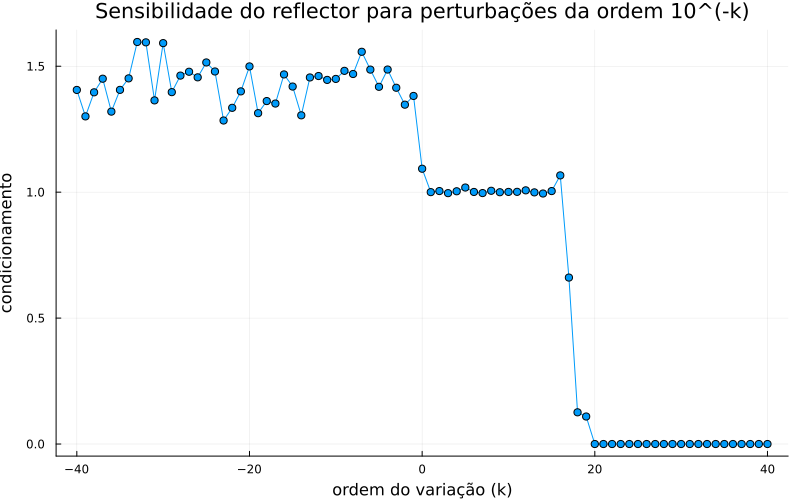

In [88]:
n = 100

x = randn(n)

conds = Float64[]
ks = Float32[]
for k in -40:40

    δx = 10.0^(-k)*randn(n)

    v,_ = reflector(x)
    vp,_ = reflector(x + δx)

    κ = norm(vp-v)/norm(δx)
    push!(conds, κ)
    push!(ks, k)
end

plot(ks, conds,
     xlabel="ordem do variação (k)",
     ylabel="condicionamento",
     title="Sensibilidade do reflector para perturbações da ordem 10^(-k)",
     legend=false,
     marker=:circle,
     line=:solid, size=(800,500))

Note que realmente os condicionamentos não passaram de 2. Para perturbações pequenas, menores que 1 o condicionamento é aproximanademte 1, e menores que $10^{-20}$, o condicionamento é 0.

-------------------------------------------

#### Letra e)

In [62]:
println("TESTE FLOAT64")

x64 = Float64[1.0, 1e-2, 1e-4, 1e-6, 1e-8, 1e-12]

v64, beta64 = reflector(x64)

qx64 = apply_reflector(v64, beta64, x64)

println("v = ", v64)
println("beta = ", beta64)
println("Qx = ", qx64)

println()
println("TESTE FLOAT32")

x32 = Float32[1.0, 1e-2, 1e-4, 1e-6, 1e-8, 1e-12]

v32, beta32 = reflector(x32)

qx32 = apply_reflector(v32, beta32, x32)

println("v = ", v32)
println("beta = ", beta32)
println("Qx = ", qx32)

TESTE FLOAT64
v = [-5.000375031252734e-5, 0.01, 0.0001, 1.0e-6, 1.0e-8, 1.0e-12]
beta = 19997.500037500628
Qx = [1.0000500037503126, -1.734723475976807e-18, -1.3552527156068805e-20, 0.0, -1.6543612251060553e-24, -2.0194839173657902e-28]

TESTE FLOAT32
v = Float32[-5.0003746f-5, 0.01, 0.0001, 1.0f-6, 1.0f-8, 1.0f-12]
beta = 19997.502
Qx = Float32[1.00005, -1.8626451f-9, -1.4551915f-11, -1.1368684f-13, -1.7763568f-15, -1.0842022f-19]


Dessa tabela podemos verificar que: 
- os valores de v são praticamente iguais nas duas representações, mas em Float32 há menos dígitos significativos disponíveis. Isso significa que pequenas diferenças podem ser mascaradas ou arredondadas.
- Nos valores de $\beta$ é visível a perda de precisão, o que vai afetar na precisão das contas futuras também.
- Em $Qx$ os termos de Float64 vão até ordem de 1e-28, enquanto que em Float32, os termos param em torno de 1e-19. Inegável a diferença de precisão.

Tipagem verificada

----------------------------------

#### Letra f)

Sabemos que o refletor de Hoseholder é $I - 2 \frac{vv^*}{v^* v}$

Isso porque, como dissemos no item a, ele reflete $x$ em relação ao hiperplano perpendicular a $v$ para que se alinhe com $ e_1$, ou seja, projetar $x$ para obter $‖x‖e_1$. 

Assim, essa projeção diretamente não nos dará uma projeção ortogonal, mas podemos projetar $x$ na bissetriz do ângulo entre $x$ e $‖x‖e_1$, que forma um ângulo de 90° com $v$. Então:
$$
P = I - \frac{vv^*}{v^* v} 
$$

Mas como precisamos percorrer duas vezes a distância que acabamos de percorrer, então, a equação final para o refletor de Householder é:
$$
Q_v = I - 2 \frac{vv^*}{v^* v}
$$

E, portanto: $\beta = \frac{2}{v^* v}$

In [ ]:
function calc_beta(v)

    vv = dot(v,v)

    return 2 / vv
end

calc_beta (generic function with 1 method)

In [74]:
println("TESTES FLOAT64")

x = Float64[1.0, 1e-2, 1e-4, 1e-6, 1e-8, 1e-12]
betas1 = Float64[]
betas2 = Float64[]
erros = Float64[]

for i in x
    v,beta1 = reflector(x)
    beta2 = calc_beta(v)
    erro = abs(beta1-beta2)
    push!(betas1, beta1)
    push!(betas2, beta2)
    push!(erros, erro)
end

println("beta via x = ", betas1)
println("beta via v = ", betas2)
println("erros = ", erros)

println()

println("TESTES FLOAT32")

x = Float32[1.0, 1e-2, 1e-4, 1e-6, 1e-8, 1e-12]
beta1 = Float32[]
beta2 = Float32[]
erros = Float32[]

for i in x
    v,beta1 = reflector(x)
    beta2 = calc_beta(v)
    erro = abs(beta1-beta2)
    push!(betas1, beta1)
    push!(betas2, beta2)
    push!(erros, erro)
end

println("betas via x = ", betas1)
println("betas via v = ", betas2)
println("erros = ", erros)

TESTES FLOAT64
beta via x = [19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.500037500628]
beta via v = [19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.500037500628]
erros = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

TESTES FLOAT32
betas via x = [19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.501953125, 19997.501953125, 19997.501953125, 19997.501953125, 19997.501953125, 19997.501953125]
betas via v = [19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.500037500628, 19997.5, 19997.5, 19997.5, 19997.5, 19997.5, 19997.5]
erros = Float32[0.001953125, 0.001953125, 0.001953125, 0.001953125, 0.001953125, 0.001953125]


Observamos que não há muita diferença ao calcular $\beta$ a partir de $x$ ou apenas de $v$, mesmo com $x$ quase alinhado com $e_1$, pois os erros residuais são consideravelmente pequenos.

Além disso, ao repetir os testes, notamos que dessa vez  os valores de $\beta$ calculados usando os tipos Float32 ou Float64 são parecidíssimos. Ou seja, são funções de cálculo de $\beta$ mais estáveis que as funções do item anterior. 

----------------------------------------

#### Letra g)

Fórmula para calcular $v$ que não seja tão sensível a $x_1$

In [78]:
function reflector_insensible(x)

    nx = norm(x)

    v = copy(x)

    v[1] -= nx

    beta = 2 / dot(v,v)

    return v,beta
end

reflector_insensible (generic function with 1 method)

Experimento de condicionamento: Tomar vetores quase paralelos a $e_1$: $x = (1, \epsilon, \epsilon)$

Com o gráfico abaixo, devemos verificar que o condicionamento aumenta significativamente para uma variação pequena, provando o mau-condicionamento.
Para evidenciar isso criamos a nova função reflector, que faz os cálculos sem tratamento de casos:

In [109]:
function reflector_naive(x)
    T = eltype(x)

    nx = norm(x)

    v = copy(x)
    #v[1] -= nx

    # y2 = sum(abs2, @view x[2:end])
    y2 = sum(abs2, x[2:end])


    v[1] = x[1] - nx

    beta = inv(nx * (nx - x[1]))

    return v, beta
end

reflector_naive (generic function with 1 method)

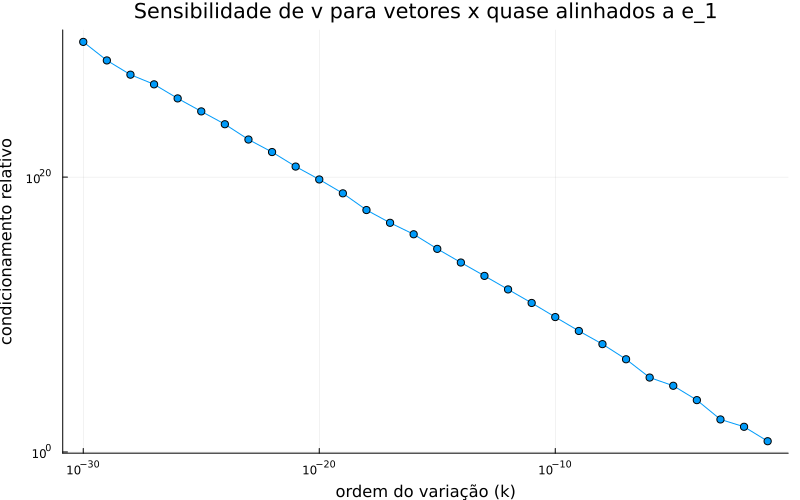

In [123]:
conds = Float64[]
ks = Float32[]
for k in 1:30
    eps = 10.0^(-k)

    x = Float64[1.0, eps, eps]

    δx = 10.0^(-k)*randn(3)

    v,_ = reflector_naive(x)
    vp,_ = reflector_naive(x + δx)

    κrel = (norm(vp-v)/norm(v)) / (norm(δx)/norm(x))
    push!(conds, κrel)
    push!(ks, eps)
end

plot(ks, conds,
     xlabel="ordem do variação (k)",
     ylabel="condicionamento relativo",
     xscale=:log10,
     yscale=:log10,
     title="Sensibilidade de v para vetores x quase alinhados a e_1",
     legend=false,
     marker=:circle,
     line=:solid, size=(800,500))

Está confirmado que o condicionamento relativo explode, chegando à ordem de $10^20$.

eps                     erro_relativo
0.1            2.3248583572303497e-16
0.010000000000000002            6.7721960739557365e-15
0.001            8.995593644402822e-14
0.0001            7.618871003239476e-14
1.0e-5            5.854163260782064e-13
1.0e-6            6.286220497833137e-11
1.0000000000000001e-7            5.6517477884539856e-11
1.0e-8            7.071067811865475e-9
1.0e-9            7.071067811865476e-10
1.0e-10            7.071067811865475e-11
1.0e-11            7.071067811865475e-12
1.0000000000000002e-12            7.071067811865476e-13
1.0e-13            7.071067811865475e-14
1.0e-14            7.071067811865476e-15
1.0e-15            7.071067811865475e-16
1.0e-16            7.071067811865476e-17


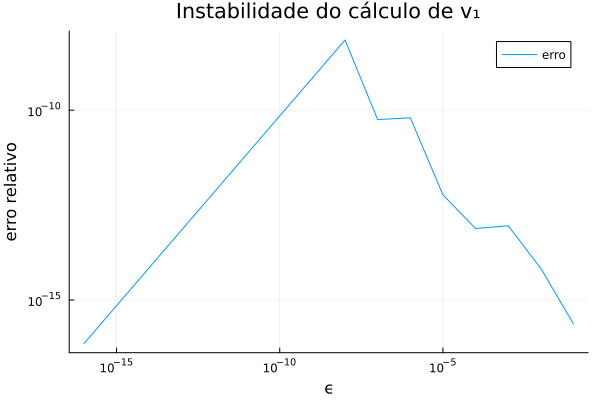

In [87]:
epss = Float64[]
errs = Float64[]
println("eps                     erro_relativo")
for k in 1:16

    eps = 10.0^(-k)

    x = Float64[1.0, eps, eps]

    v_naive,_ = reflector_naive(x)

    v_stable,_ = reflector(x)

    err =
        norm(v_naive - v_stable) /
        norm(v_stable)

    push!(epss, eps)
    push!(errs, err)
    println(eps,"            ",err)
end

plot(
    epss,
    errs,
    xscale=:log10,
    yscale=:log10,
    xlabel="ϵ",
    ylabel="erro relativo",
    label="erro",
    title="Instabilidade do cálculo de v₁"
)

Visto o gráfico, parece ser uma solução cabível, as ordens dos erros são baixas, em comparação com o ganho de estabilidade.